In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from matplotlib.patches import Rectangle
from torchvision.ops import box_iou
from ultralytics import YOLO
import ultralytics

**Real YOLO26 inference**

In [2]:
MODEL_ID = "yolo26n.pt"
IMAGE_URL = "https://ultralytics.com/images/bus.jpg"

model = YOLO(MODEL_ID)

result = model.predict(
    source=IMAGE_URL,
    conf=0.25,
    verbose=False
)[0]

print("Original image shape:", result.orig_shape)
print("Number of detections:", len(result.boxes))

Original image shape: (1080, 810)
Number of detections: 5


**Visualize detections**

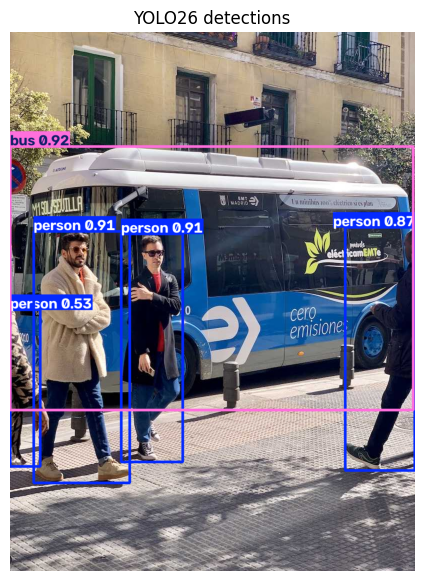

In [3]:
annotated_bgr = result.plot()
annotated_rgb = annotated_bgr[..., ::-1]

plt.figure(figsize=(10, 7))
plt.imshow(annotated_rgb)
plt.title("YOLO26 detections")
plt.axis("off")
plt.show()

**Detection output anatomy**

In [4]:
boxes = result.boxes

print("boxes.xyxy shape :", boxes.xyxy.shape)
print("boxes.xywh shape :", boxes.xywh.shape)
print("boxes.conf shape :", boxes.conf.shape)
print("boxes.cls shape :", boxes.cls.shape)

boxes.xyxy shape : torch.Size([5, 4])
boxes.xywh shape : torch.Size([5, 4])
boxes.conf shape : torch.Size([5])
boxes.cls shape : torch.Size([5])


In [5]:
number_of_show = min(5, len(boxes))

for index in range(number_of_show):
    class_id = int(boxes.cls[index].item())
    class_name = result.names[class_id]
    
    confidence = boxes.conf[index].item()
    xyxy = boxes.xyxy[index].cpu().tolist()
    
    print(f"Detection {index + 1}")
    print("Class      :", class_name)
    print("Confidence :", round(confidence, 4))
    print(
        "XYXY       :",
        [round(value, 2) for value in xyxy]
    )

Detection 1
Class      : bus
Confidence : 0.9236
XYXY       : [0.0, 229.37, 806.1, 757.09]
Detection 2
Class      : person
Confidence : 0.9126
XYXY       : [222.47, 404.94, 345.41, 861.64]
Detection 3
Class      : person
Confidence : 0.9055
XYXY       : [47.69, 399.32, 239.35, 903.02]
Detection 4
Class      : person
Confidence : 0.8701
XYXY       : [670.68, 391.53, 809.81, 878.98]
Detection 5
Class      : person
Confidence : 0.5345
XYXY       : [0.13, 556.69, 60.0, 870.1]


**Inspect all box formats**

In [ ]:
if len(boxes) > 0:
    first_index = 0
    
    print("XYXY absolute: ", boxes.xyxy[first_index].cpu().tolist())
    
    print("XYWH absolute: ", boxes.xywh[first_index].cpu().tolist()) # [center_x, center_y, width, height]
    
    print("XYXY normalized: ", boxes.xyxyn[first_index].cpu().tolist())
    
    print("XYWH normalized: ", boxes.xywhn[first_index].cpu().tolist())

XYXY absolute:  [0.0, 229.36883544921875, 806.0955810546875, 757.0858154296875]
XYWH absolute:  [403.04779052734375, 493.2273254394531, 806.0955810546875, 527.7169799804688]
XYXY normalized:  [0.0, 0.21237854659557343, 0.9951797127723694, 0.7010053992271423]
XYWH normalized:  [0.4975898563861847, 0.4566919803619385, 0.9951797127723694, 0.4886268377304077]


**Manual format conversion**

_XYXY → CXCYWH_

In [7]:
def xyxy_to_cxcywh(box):
    x1, y1, x2, y2 = box
    
    width = x2 - x1
    height = y2 - y1
    
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    
    return torch.stack([center_x, center_y, width, height])

In [8]:
first_xyxy = boxes.xyxy[0].detach().cpu()
manual_cxcywh = xyxy_to_cxcywh(first_xyxy)

library_cxcywh = boxes.xywh[0].detach().cpu()

print("Manual conversion :", manual_cxcywh)
print("Library conversion:", library_cxcywh)
torch.testing.assert_close(manual_cxcywh, library_cxcywh)
print("Conversion is correct.")

Manual conversion : tensor([403.0478, 493.2273, 806.0956, 527.7170])
Library conversion: tensor([403.0478, 493.2273, 806.0956, 527.7170])
Conversion is correct.


**Normalize for YOLO format**

In [9]:
image_height, image_width = result.orig_shape

normalization_values = torch.tensor([
    image_width, image_height,
    image_width, image_height
], dtype=torch.float32)

manual_normalized = manual_cxcywh / normalization_values

library_normalized = boxes.xywhn[0].detach().cpu()

print("Manual conversion :", manual_normalized)
print("Library conversion:", library_normalized)

torch.testing.assert_close(
    manual_normalized, library_normalized,
    rtol=1e-4, atol=1e-4
)
print("Normalization is correct.")

Manual conversion : tensor([0.4976, 0.4567, 0.9952, 0.4886])
Library conversion: tensor([0.4976, 0.4567, 0.9952, 0.4886])
Normalization is correct.


**RDD2022 conversion function**

_Pascal VOC → YOLO_

In [10]:
def voc_to_yolo(box_xyxy, image_width, image_height):
    xmin, ymin, xmax, ymax = box_xyxy
    
    box_width = xmax - xmin
    box_height = ymax - ymin
    
    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2
    
    return [
        center_x / image_width,
        center_y / image_height,
        box_width / image_width,
        box_height / image_height
    ]

In [11]:
image_width = 640
image_height = 480

voc_box = [64, 48, 320, 240]
yolo_box = voc_to_yolo(voc_box, image_width, image_height)

print("VOC box :", voc_box)
print(
    "YOLO box:",
    [round(value, 4) for value in yolo_box]
)

VOC box : [64, 48, 320, 240]
YOLO box: [0.3, 0.3, 0.4, 0.4]
